In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 150

In [22]:
# Wczytanie danych
freq_df = pd.read_csv('sound_frequency.csv')
f   = freq_df['f'].iloc[0]          # Hz, dokładna
u_f = freq_df['u_f'].iloc[0]        # 0

solutions = {
    'Woda destylowana':   pd.read_csv('distilled_water.csv'),
    '10% roztwór NaCl': pd.read_csv('10_percent_salt_water.csv'),
    '20% roztwór NaCl': pd.read_csv('20_percent_salt_water.csv'),
}

print(f'Częstotliwość: f = {f:.0f} Hz')
for name, df in solutions.items():
    print(f'{name}: {len(df)} pomiarów')

Częstotliwość: f = 2000000 Hz
Woda destylowana: 20 pomiarów
10% roztwór NaCl: 20 pomiarów
20% roztwór NaCl: 20 pomiarów


In [23]:
from scipy import stats

def linreg_lam(r_arr):
    """Regresja r_i = A·i + B; A = λ/2. Wszystkie 20 pomiarów użyte optymalnie."""
    i = np.arange(1, len(r_arr) + 1, dtype=float)
    n = len(i)
    slope, intercept, r_val, _, se = stats.linregress(i, r_arr)
    y_fit = slope * i + intercept
    s_res = np.sqrt(np.sum((r_arr - y_fit)**2) / (n - 2))
    return dict(A=slope, B=intercept, u_A=se,
                lam=2*slope, u_lam=2*se, s_res=s_res, R2=r_val**2)

wavelengths = {}
for name, df in solutions.items():
    r = df['r'].values
    res = linreg_lam(r)
    wavelengths[name] = res
    print(f'{name}:')
    print(f'  A = λ/2 = ({res["A"]:.5f} ± {res["u_A"]:.5f}) mm')
    print(f'  λ = ({res["lam"]:.4f} ± {res["u_lam"]:.4f}) mm,  R² = {res["R2"]:.7f}')

Woda destylowana:
  A = λ/2 = (0.37230 ± 0.00027) mm
  λ = (0.7446 ± 0.0005) mm,  R² = 0.9999907
10% roztwór NaCl:
  A = λ/2 = (0.40141 ± 0.00022) mm
  λ = (0.8028 ± 0.0004) mm,  R² = 0.9999946
20% roztwór NaCl:
  A = λ/2 = (0.42792 ± 0.00031) mm
  λ = (0.8558 ± 0.0006) mm,  R² = 0.9999904


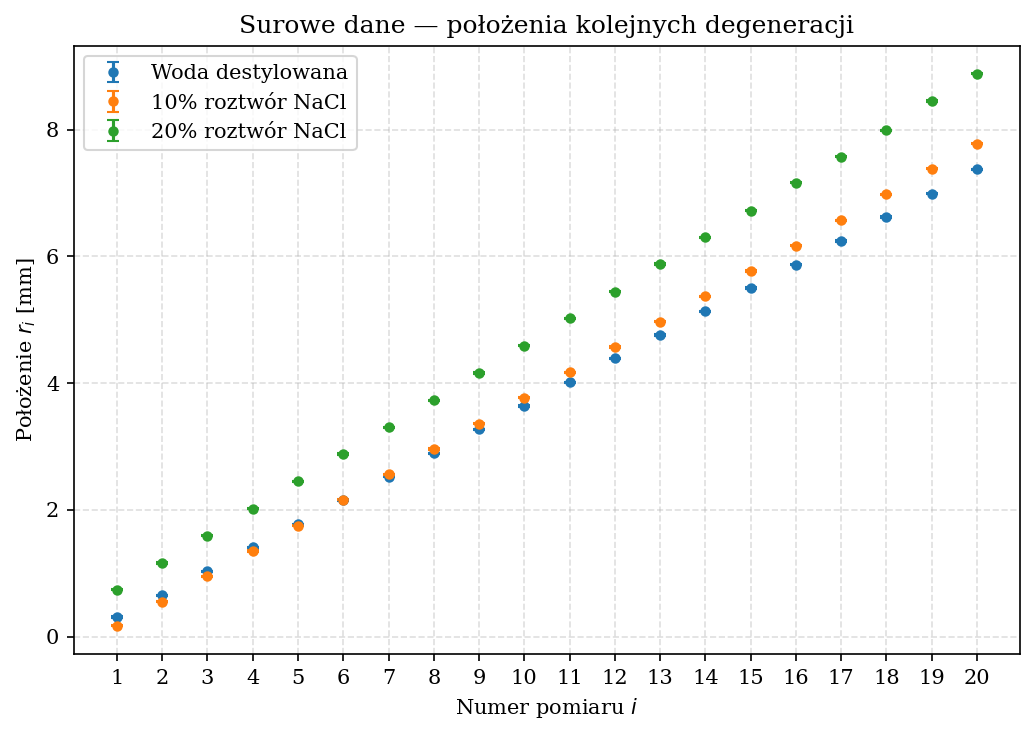

Zapisano raw_data.pdf


In [24]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(7, 5))
for (name, df), color in zip(solutions.items(), colors):
    r   = df['r'].values
    u_r = df['u_r'].values
    i   = np.arange(1, len(r) + 1)
    ax.errorbar(i, r, yerr=u_r, fmt='o', markersize=4,
                capsize=3, label=name, color=color)

ax.set_xlabel('Numer pomiaru $i$')
ax.set_ylabel('Położenie $r_i$ [mm]')
ax.set_title('Surowe dane — położenia kolejnych degeneracji')
ax.set_xticks(np.arange(1, 21))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('raw_data.pdf')
plt.show()
print('Zapisano raw_data.pdf')

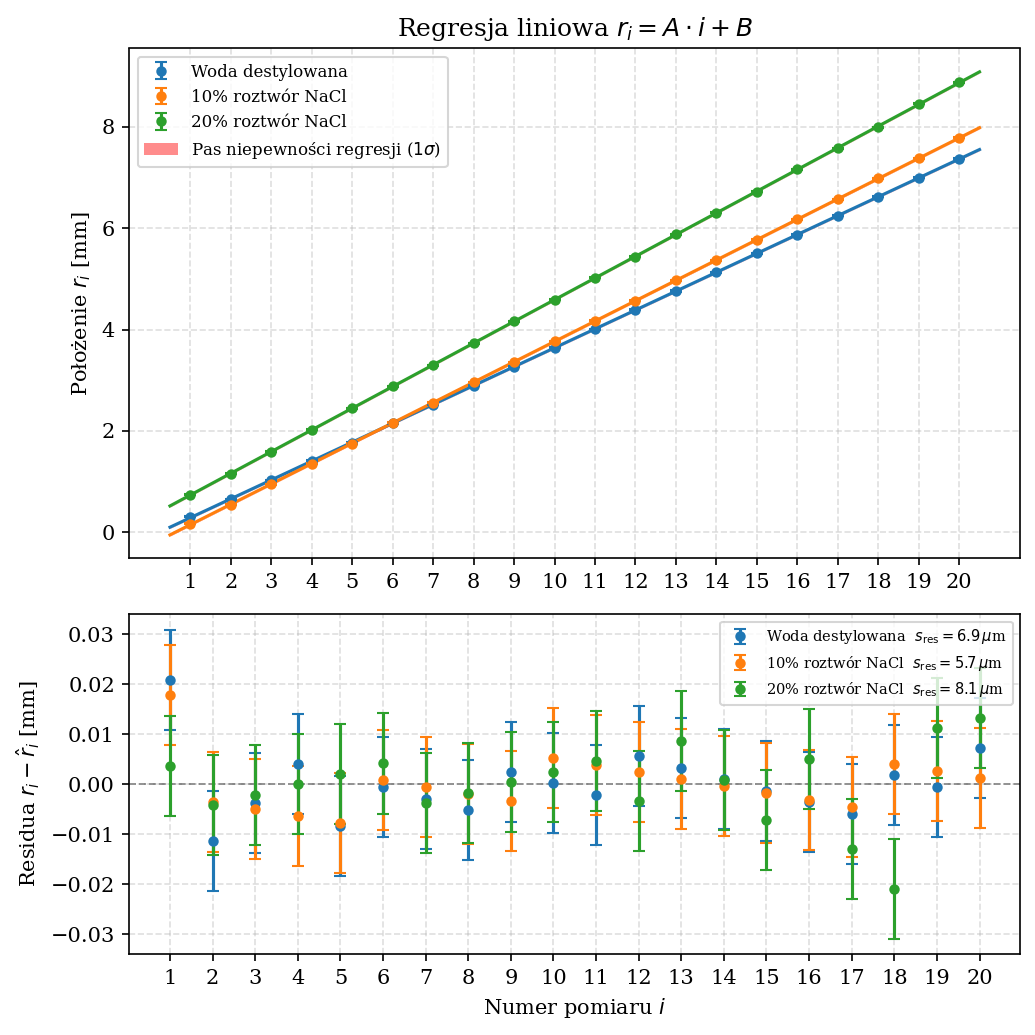

Zapisano regression_fit.pdf


In [25]:
import matplotlib.patches as mpatches

i_nodes = np.arange(1, 21)
i_dense = np.linspace(0.5, 20.5, 400)

fig, (ax_fit, ax_res) = plt.subplots(
    2, 1, figsize=(7, 7),
    gridspec_kw={'height_ratios': [3, 2]},
    sharex=False
)

for (name, df), color in zip(solutions.items(), colors):
    r     = df['r'].values
    u_r   = df['u_r'].values
    res   = wavelengths[name]
    A, B, s_res = res['A'], res['B'], res['s_res']

    n      = len(r)
    i_mean = i_nodes.mean()
    Sxx    = np.sum((i_nodes - i_mean) ** 2)

    y_line  = A * i_dense + B
    se_band = s_res * np.sqrt(1/n + (i_dense - i_mean)**2 / Sxx)
    residuals = r - (A * i_nodes + B)

    ax_fit.plot(i_dense, y_line, color=color, linewidth=1.5, zorder=3)
    ax_fit.fill_between(i_dense, y_line - se_band, y_line + se_band,
                        color='red', alpha=0.20, zorder=2)
    ax_fit.errorbar(i_nodes, r, yerr=u_r, fmt='o', markersize=4,
                    capsize=3, label=name, color=color, zorder=4)

    ax_res.errorbar(i_nodes, residuals, yerr=u_r, fmt='o', markersize=4,
                    capsize=3, color=color, zorder=3,
                    label=f'{name}  $s_{{\\rm res}}={s_res*1e3:.1f}\\,\\mu$m')

ax_res.axhline(0, color='gray', linewidth=0.9, linestyle='--', zorder=1)

red_patch = mpatches.Patch(facecolor='red', alpha=0.45,
                            label='Pas niepewności regresji ($1\\sigma$)')
h, l = ax_fit.get_legend_handles_labels()
ax_fit.legend(h + [red_patch], l + [red_patch.get_label()], fontsize=8)
ax_res.legend(fontsize=7, loc='upper right')

ax_fit.set_ylabel('Położenie $r_i$ [mm]')
ax_fit.set_title('Regresja liniowa $r_i = A \\cdot i + B$')
ax_fit.set_xticks(np.arange(1, 21))
ax_fit.grid(True, linestyle='--', alpha=0.4)

ax_res.set_xlabel('Numer pomiaru $i$')
ax_res.set_ylabel('Residua $r_i - \\hat{r}_i$ [mm]')
ax_res.set_xticks(np.arange(1, 21))
ax_res.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
fig.savefig('regression_fit.pdf')
plt.show()
print('Zapisano regression_fit.pdf')

In [26]:
results = {}
print(f'Częstotliwość f = {f:.6e} Hz  (u_f = {u_f})')
print()
for name, res in wavelengths.items():
    lam_m   = res['lam']   * 1e-3
    u_lam_m = res['u_lam'] * 1e-3
    v   = f * lam_m
    u_v = f * u_lam_m
    results[name] = {'lam_mean': res['lam'], 'u_lam': res['u_lam'], 'v': v, 'u_v': u_v}
    print(f'{name}:')
    print(f'  λ = ({res["lam"]:.4f} ± {res["u_lam"]:.4f}) mm')
    print(f'  v = ({v:.1f} ± {u_v:.1f}) m/s')
    print()

Częstotliwość f = 2.000000e+06 Hz  (u_f = 0)

Woda destylowana:
  λ = (0.7446 ± 0.0005) mm
  v = (1489.2 ± 1.1) m/s

10% roztwór NaCl:
  λ = (0.8028 ± 0.0004) mm
  v = (1605.6 ± 0.9) m/s

20% roztwór NaCl:
  λ = (0.8558 ± 0.0006) mm
  v = (1711.7 ± 1.3) m/s



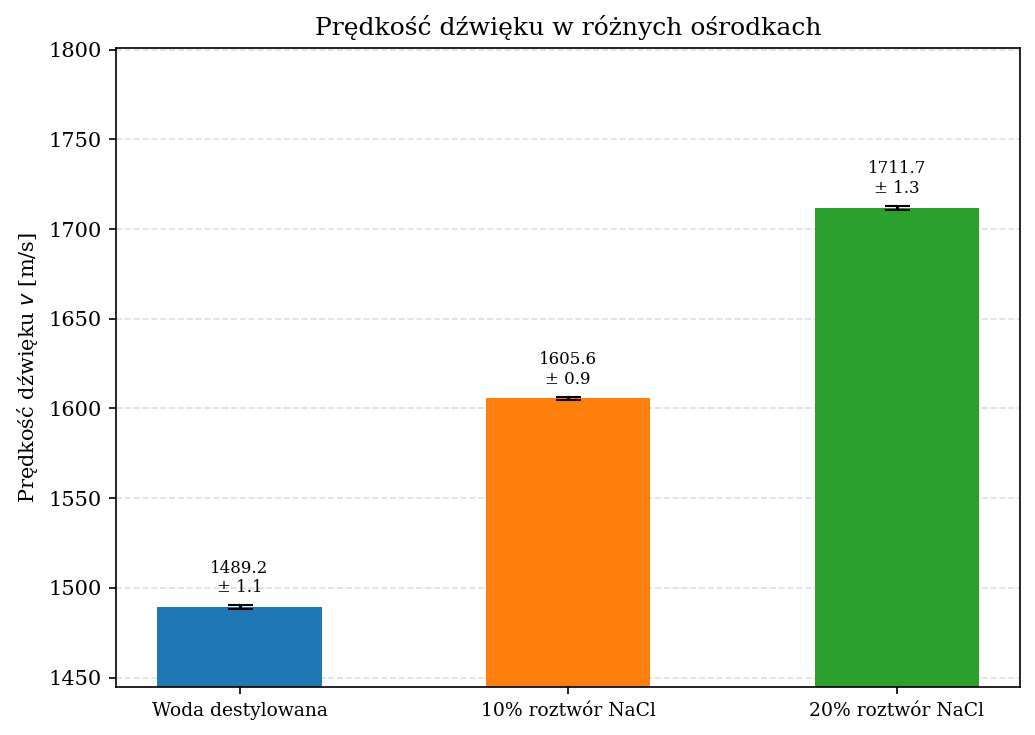

Zapisano velocities.pdf


In [27]:
import math

labels = list(results.keys())
v_vals = [results[n]['v']   for n in labels]
u_vals = [results[n]['u_v'] for n in labels]

# sufit do 1 miejsca po przecinku
u_disp = [math.ceil(u * 10) / 10 for u in u_vals]
v_disp = [round(v, 1)            for v in v_vals]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, v_disp, yerr=u_disp, color=colors, capsize=6,
              error_kw={'elinewidth': 1.5, 'ecolor': 'black'},
              width=0.5, zorder=2)

for bar, v, u in zip(bars, v_disp, u_disp):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + u + 5,
            f'{v:.1f}\n± {u:.1f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Prędkość dźwięku $v$ [m/s]')
ax.set_title('Prędkość dźwięku w różnych ośrodkach')
ax.set_ylim(min(v_disp) * 0.97, max(v_disp) * 1.05 + max(u_disp) * 3)
ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)
fig.tight_layout()
fig.savefig('velocities.pdf')
plt.show()
print('Zapisano velocities.pdf')